# 02 · Encoder: pretrained Uni-Sign (pose) vs v1 · fine-tuning adapter
**E1** = a new signer performs a dictionary sign; rank of the correct sign in the gallery.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

In [2]:
pilot = read_json(REP/'v4_eval_enc_pilot.json'); note = pilot.pop('_note', '')
print(note)
pd.DataFrame(pilot).T.sort_values('MRR', ascending=False)

E1 restricted to the pilot gallery (932 sign variants); val n=58, test n=56; test csl_stage1 up1/ctx + test v1 rows not run (job stopped: VRAM contention)


,R1,R5,R10,MRR,median_rank,gallery
test|wlasl|up2|ctx|mean,0.232,0.500,0.536,0.342,6.0,932.0
val|wlasl|up1|ctx|mean,0.241,0.448,0.483,0.337,14.0,932.0
test|wlasl|up1|ctx|mean,0.179,0.429,0.589,0.308,8.0,932.0
val|wlasl|up2|ctx|mean,0.207,0.397,0.448,0.293,18.0,932.0
test|wlasl|up2|ctx|meanmax,0.179,0.339,0.429,0.263,31.0,932.0
val|wlasl|up2|ctx|meanmax,0.190,0.345,0.345,0.255,60.0,932.0
val|wlasl|up2|gcn|meanmax,0.103,0.172,0.224,0.145,79.0,932.0
val|wlasl|up1|gcn|mean,0.086,0.155,0.155,0.130,75.0,932.0
val|csl_stage1|up2|gcn|meanmax,0.086,0.172,0.190,0.128,152.0,932.0
test|wlasl|up1|gcn|mean,0.054,0.161,0.232,0.120,59.0,932.0


In [3]:
ev = read_json(REP/'v4_eval.json')
display(pd.DataFrame({k: v for k, v in ev.items() if isinstance(v, dict)}).T)
if 'E5|per_clip' in ev: display(pd.DataFrame(ev['E5|per_clip']))

,R1,R1_ci95,R5,R5_ci95,R10,MRR,median_rank,n,vocab
E1|val|ttrs_train_only,0.137931,0.088745,0.275862,0.115027,0.310345,0.196432,75.0,58.0,4558.0
E1|test|ttrs_train_only,0.160714,0.096193,0.285714,0.118322,0.321429,0.218726,29.5,56.0,4558.0
E1|val|ttrs_train+youtube,0.120690,0.083839,0.275862,0.115027,0.310345,0.191045,75.0,58.0,4568.0
E1|test|ttrs_train+youtube,0.196429,0.104058,0.321429,0.122321,0.357143,0.254553,17.5,56.0,4568.0
E5|youtube_title_clips_vs_full_TTRS,0.266667,0.223792,0.400000,0.247923,0.400000,0.303510,45.0,15.0,4591.0
"LESSON|mined_vs_ttrs_bank (silver, selection-biased)",0.687783,0.061096,1.000000,0.000000,1.000000,0.828808,1.0,221.0,4591.0


,word,in_ttrs,top5
0,ดุด่า,False,"[แนวตั้ง, คำถาม, พูดน้อย, ถาม, คนแก่]"
1,ช่วย,True,"[เครื่องหนีบผมให้ตรง, มะเขือ, เบียดผู้อื่น, ช่วย, จิตใจดี]"
2,นอนไม่หลับ,True,"[หมอน, วัดพระเชตุพน, ยุยง, ระนอง, เส้นประสาท]"
3,ปัสสาวะ,True,"[กระเพาะปัสสวะ, กระเพราะอาหาร, ผ้าขาวม้า, โครโมโซม, เสื้อแจ็คเก็ต]"
4,ขับรถยนต์,False,"[รถยนต์, ขับ, ท้าคนอื่นสองคน, โดยสารร่วมกัน, ลานจอดรถ]"
5,นอนหลับ,True,"[หมอน, วัดพระเชตุพน, ซุบซิบ, เตียงนอน, ที่นอน, ห้องนอน]"
6,บอกลา,False,"[เบียร์, จินตนาการเกินความจริง, ไม่ใช่, จะทำจริง ๆ, เลี่ยง]"
7,หูหนวก,True,"[คนหูหนวก, บกพร่องทางการได้ยิน, จำคนผิด, ช่างสร้างสรรค์, พูดกลับกลอก]"
8,ขอบคุณ,True,"[นอน, ซุบซิบ, กราบ, แคน, กระซิบ]"
9,ถอดเสื้อ,False,"[ยืด, การระเบิดอย่างรุนแรง, เชือก, ซ้าย, ความสุข]"


adapter selected: False | rule: use adapter iff val MRR +0.01


,zero-shot,adapter
MRR,,
val,0.191045,0.202653
test,0.254553,0.245228


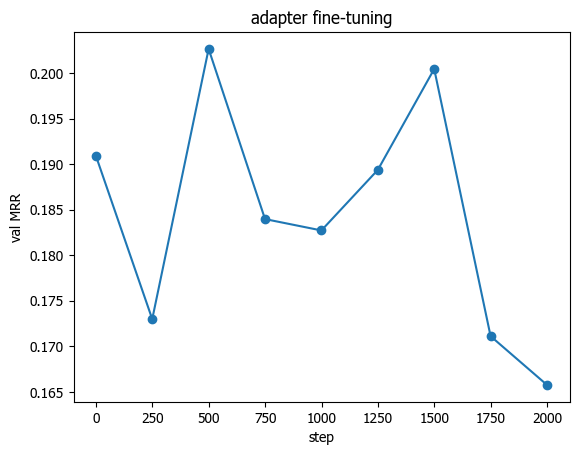

In [4]:
ad = read_json(REP/'v4_adapter.json')
print('adapter selected:', ad['selected'], '| rule:', ad['rule'])
display(pd.DataFrame({'zero-shot': {p: ad['zero_shot'][p]['MRR'] for p in ('val','test')}, 'adapter': {p: ad['adapter'][p]['MRR'] for p in ('val','test')}}).rename_axis('MRR'))
h = pd.DataFrame(ad['hist']); plt.plot(h.step, h.MRR, marker='o'); plt.xlabel('step'); plt.ylabel('val MRR'); plt.title('adapter fine-tuning'); plt.show()